# Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


PLOT_FOLDER = "plots/"

df = pd.read_csv("results.csv")
df.head()

,Model Name,Dataset Size,Translation X,Translation Y,Rotation,Scale,Shear X,Shear Y,Top-1 Accuracy,Top-5 Accuracy,Time
0,vit_base,5000,0,0,0.0,1.0,0,0,0.8162,0.9530,33.03
1,vit_base,5000,25,0,0.0,1.0,0,0,0.8110,0.9566,18.18
2,vit_base,5000,0,25,0.0,1.0,0,0,0.8038,0.9506,18.37
3,vit_base,5000,-25,0,0.0,1.0,0,0,0.8108,0.9530,18.36
4,vit_base,5000,0,-25,0.0,1.0,0,0,0.8080,0.9526,18.25


### Translation

In [56]:
def plot_translations_2D(df, model_name="model", title="Title"):
    # locate baseline (no translation, no rotation, scale=1, no shear)
    baseline_row = df[
        (df["Model Name"] == model_name)
        & (df["Translation X"] == 0)
        & (df["Translation Y"] == 0)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] == 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
    ]
    if baseline_row.empty:
        print("Baseline row not found!")
        return
    baseline_top1 = baseline_row["Top-1 Accuracy"].values[0]
    baseline_top5 = baseline_row["Top-5 Accuracy"].values[0]

    # filter rows with translations at ±25 and ±50 (only translations, no other augmentations)
    translation_rows = df[
        (df["Model Name"] == model_name)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] == 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
        & (
            ((abs(df["Translation X"]) == 25) & (df["Translation Y"] == 0)) |
            ((df["Translation X"] == 0) & (abs(df["Translation Y"]) == 25)) |
            ((abs(df["Translation X"]) == 50) & (df["Translation Y"] == 0)) |
            ((df["Translation X"] == 0) & (abs(df["Translation Y"]) == 50))
        )
    ]

    # group by translation magnitude (25 or 50)
    translation_rows = translation_rows.copy()
    translation_rows["magnitude"] = np.where(
        (abs(translation_rows["Translation X"]) == 25) | (abs(translation_rows["Translation Y"]) == 25),
        25,
        50
    )

    # average top-1 and top-5 for each magnitude
    avg_results = translation_rows.groupby("magnitude")[["Top-1 Accuracy", "Top-5 Accuracy"]].mean().reset_index()

    # prepare data for bar plot
    magnitudes = avg_results["magnitude"].values
    top1_avgs = avg_results["Top-1 Accuracy"].values
    top5_avgs = avg_results["Top-5 Accuracy"].values

    # bar plot
    x = np.arange(len(magnitudes)+1)  # positions for bars
    width = 0.35  # width of bars

    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.bar(x - width/2, [baseline_top1] + list(top1_avgs), width, label='Top-1 Accuracy', color='skyblue')
    bars2 = ax.bar(x + width/2, [baseline_top5] + list(top5_avgs), width, label='Top-5 Accuracy', color='orange')

    # place a dotted line at the baseline values
    ax.axhline(baseline_top1, color='skyblue', linestyle='--', label='Baseline Top-1')
    ax.axhline(baseline_top5, color='orange', linestyle=':', label='Baseline Top-5')

    # add baseline bars at position 0
    # ax.bar(-width/2, baseline_top1, width, color='skyblue')
    # ax.bar(width/2, baseline_top5, width, color='orange')

    ax.set_xlabel('Translation Magnitude')
    ax.set_ylabel('Accuracy')
    ax.set_title(f"{title}", fontsize=20)
    ax.set_ylim(0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(['Baseline'] + [f'{int(m)}' for m in magnitudes])

    # Set the axis fontsize to 16
    ax.tick_params(axis='both', which='major', labelsize=16)

    # set the axis titlesize to 18
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)

    # ax.legend(loc="center", framealpha=1.0)

    plt.savefig(f"{PLOT_FOLDER}{model_name}_translations_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

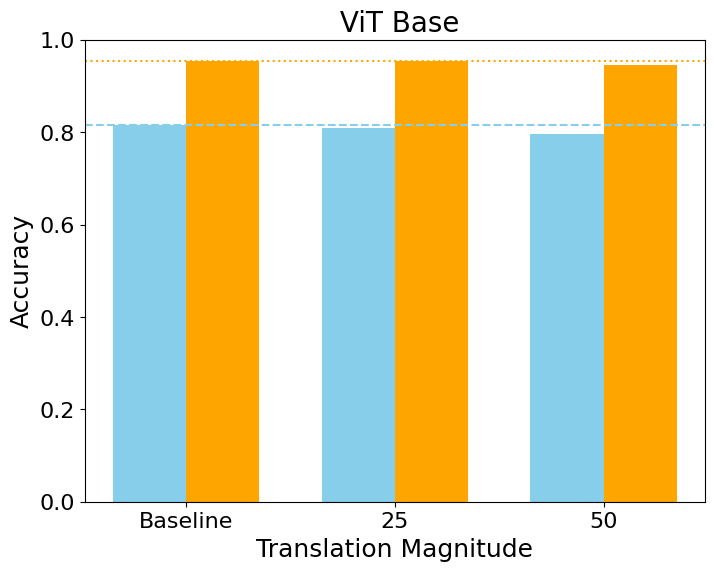

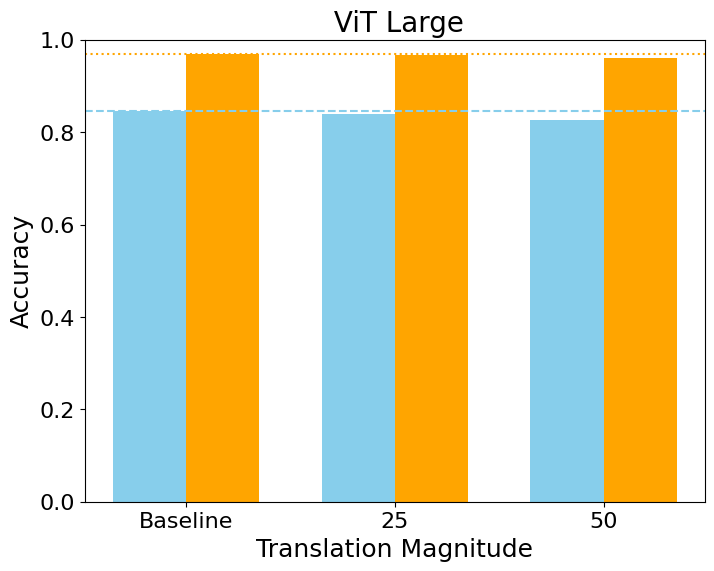

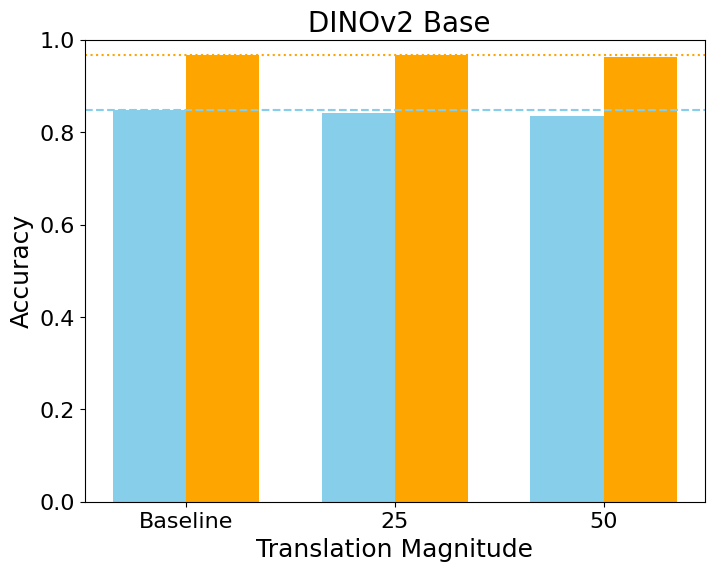

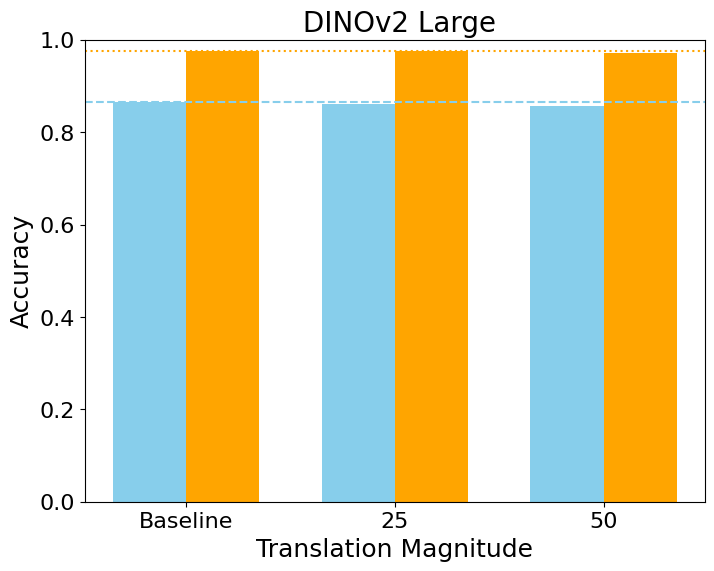

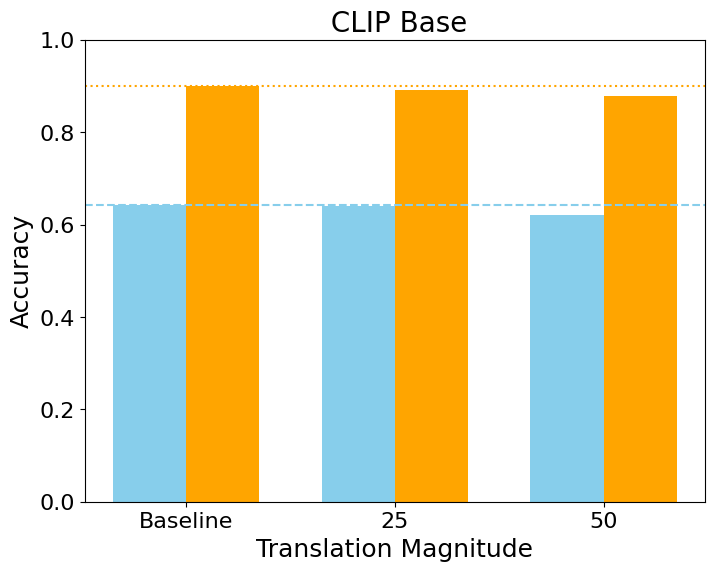

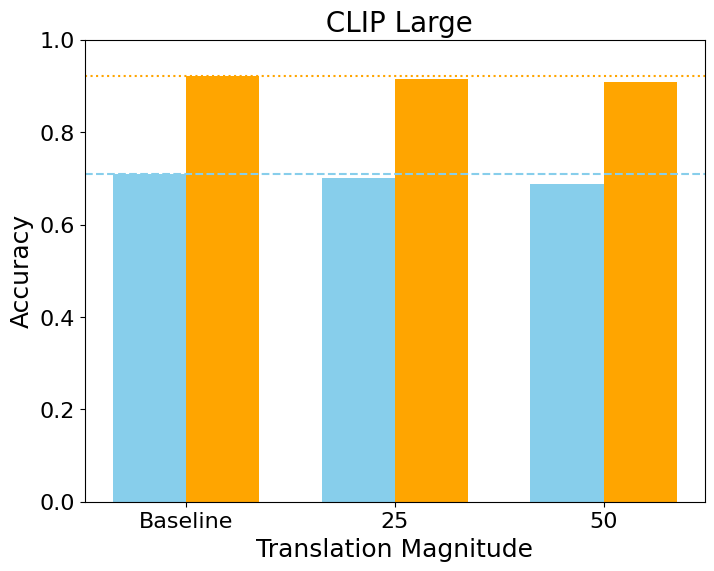

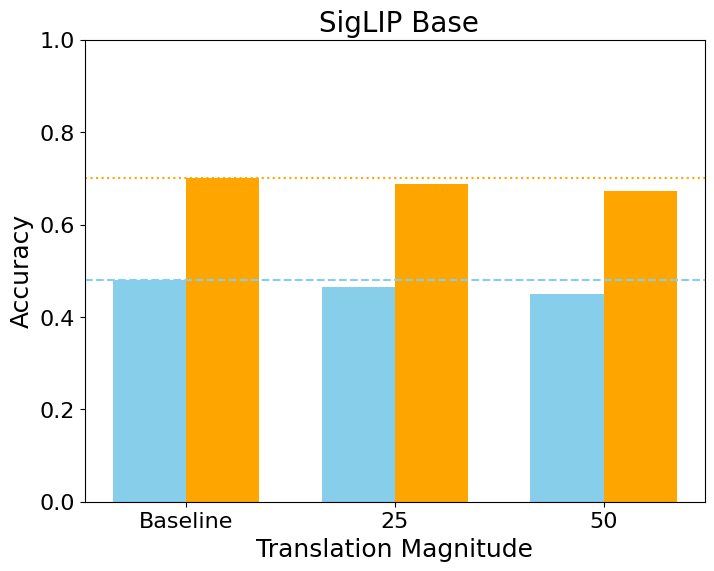

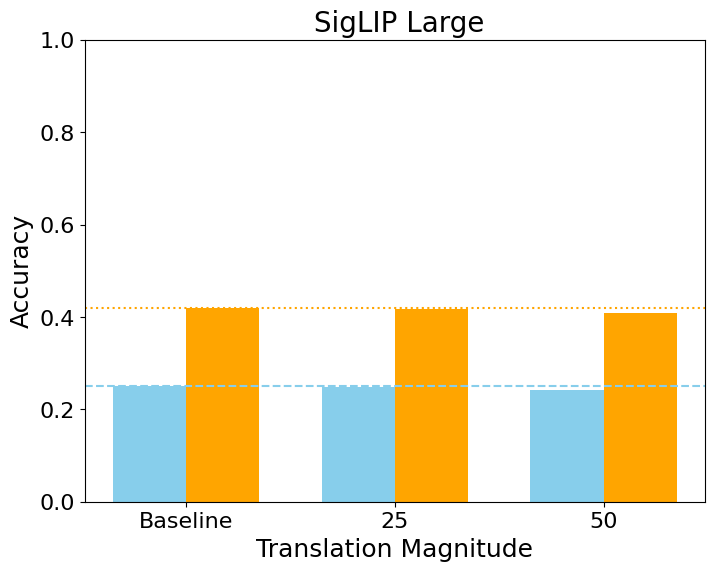

In [57]:
plot_translations_2D(df, model_name="vit_base", title=" ViT Base")
plot_translations_2D(df, model_name="vit_large", title=" ViT Large")
plot_translations_2D(df, model_name="dinov2_base", title=" DINOv2 Base")
plot_translations_2D(df, model_name="dinov2_large", title=" DINOv2 Large")
plot_translations_2D(df, model_name="clip_base", title=" CLIP Base")
plot_translations_2D(df, model_name="clip_large", title=" CLIP Large")
plot_translations_2D(df, model_name="siglip_base", title=" SigLIP Base")
plot_translations_2D(df, model_name="siglip_large", title=" SigLIP Large")

In [ ]:
def plot_translations_3D(df, model_name="model", title="Title"):
    baseline_row = df[
        (df["Model Name"] == model_name)
        & (df["Translation X"] == 0)
        & (df["Translation Y"] == 0)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] == 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
    ]
    if len(baseline_row) > 0:
        baseline = baseline_row["Top-1 Accuracy"].iloc[0]
        baseline5 = baseline_row["Top-5 Accuracy"].iloc[0]
    else:
        baseline = df["Top-1 Accuracy"].max()  # fallback
        baseline5 = df["Top-5 Accuracy"].max()  # fallback

    translate_df = df[
        (df["Model Name"] == model_name)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] == 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
        & ((df["Translation X"] != 0) | (df["Translation Y"] != 0))
    ]

    # Plot on 3D bar plot
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    x = translate_df["Translation X"].values
    y = translate_df["Translation Y"].values
    z = np.zeros_like(x)  # start bars at z=0
    dx = dy = 5  # width of the bars
    dz = translate_df["Top-1 Accuracy"].values  # height of the bars relative to baseline
    ax.bar3d(x, y, z, dx, dy, dz, shade=True)
    ax.set_xlabel("Translation X")
    ax.set_ylabel("Translation Y")
    ax.set_zlabel("Top-1 Accuracy")
    ax.set_title(title, fontsize=20)
    
    plt.savefig(f"{PLOT_FOLDER}{model_name}_translation_3d_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

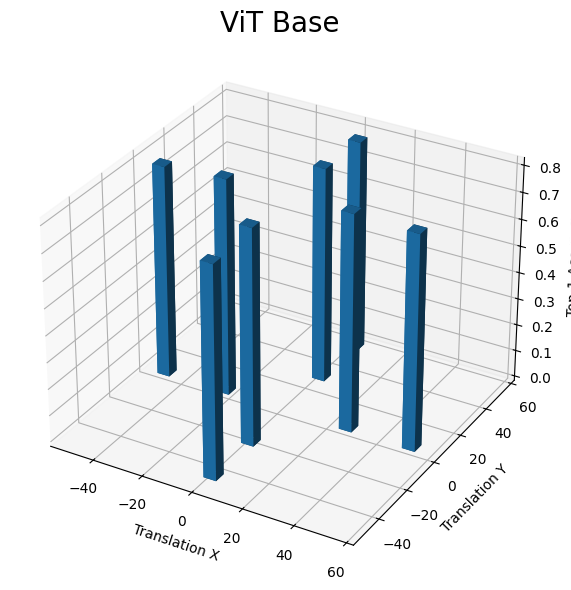

In [11]:
plot_translations_3D(df, model_name="vit_base", title="ViT Base")

### Rotation

In [41]:
# Polar plot: baseline vs rotations
def plot_rotations_polar(df, model_name="model", title="Title"):
    # locate baseline (no translation, no rotation, scale=1, no shear)
    baseline_row = df[
        (df["Model Name"] == model_name)
        & (df["Translation X"] == 0)
        & (df["Translation Y"] == 0)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] == 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
    ]
    if len(baseline_row) > 0:
        baseline = baseline_row["Top-1 Accuracy"].iloc[0]
        baseline5 = baseline_row["Top-5 Accuracy"].iloc[0]
    else:
        baseline = df["Top-1 Accuracy"].max()  # fallback
        baseline5 = df["Top-5 Accuracy"].max()  # fallback

    # select rotation-only rows (no translation, scale=1, no shear)
    rot_df = df[
        (df["Model Name"] == model_name)
        & (df["Translation X"] == 0)
        & (df["Translation Y"] == 0)
        & (df["Scale"] == 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
        & (df["Rotation"] != 0.0)
    ]
    rot_df = rot_df.sort_values("Rotation")
    angles = rot_df["Rotation"].values
    r_vals = rot_df["Top-1 Accuracy"].values
    r5_vals = rot_df["Top-5 Accuracy"].values
    # include baseline at 0 degrees in the plotted points
    angles_with_baseline = np.concatenate(([0.0], angles))
    r_with_baseline = np.concatenate(([baseline], r_vals))
    r5_with_baseline = np.concatenate(([baseline5], r5_vals))
    # sort by angle so the polar line is ordered correctly
    order = np.argsort(angles_with_baseline)
    angles_deg = angles_with_baseline[order]
    r = r_with_baseline[order]
    r5 = r5_with_baseline[order]
    thetas = np.deg2rad(angles_deg)

    # close the loop for a continuous polar line
    thetas_closed = np.concatenate([thetas, thetas[:1]])
    r_closed = np.concatenate([r, r[:1]])
    r_closed5 = np.concatenate([r5, r5[:1]])

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, polar=True)
    ax.plot(thetas_closed, r_closed, marker="o", label="Rotation Top-1", color="skyblue")
    ax.plot(thetas_closed, r_closed5, marker="s", label="Rotation Top-5", color="C1")
    # baseline as a dashed circle
    ax.plot(
        np.linspace(0, 2 * np.pi, 200),
        np.full(200, baseline),
        linestyle="--",
        color="skyblue",
        label=f"Baseline Top-1",
    )
    # top-5 baseline as a dotted circle
    ax.plot(
        np.linspace(0, 2 * np.pi, 200),
        np.full(200, baseline5),
        linestyle=":",
        color="C1",
        label=f"Baseline Top-5",
    )
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    # label the grid at rotation angles
    if len(angles_deg) > 0:
        ax.set_thetagrids(angles_deg)
    ax.set_title(title, fontsize=20)
    ax.set_rlim(0, 1.0)

    # Set the axis fontsize to 16
    # ax.tick_params(axis='both', which='major', labelsize=16)

    # set the axis titlesize to 18
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
    
    # ax.legend(loc="center", framealpha=1.0)

    plt.savefig(f"{PLOT_FOLDER}{model_name}_rotation_polar_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

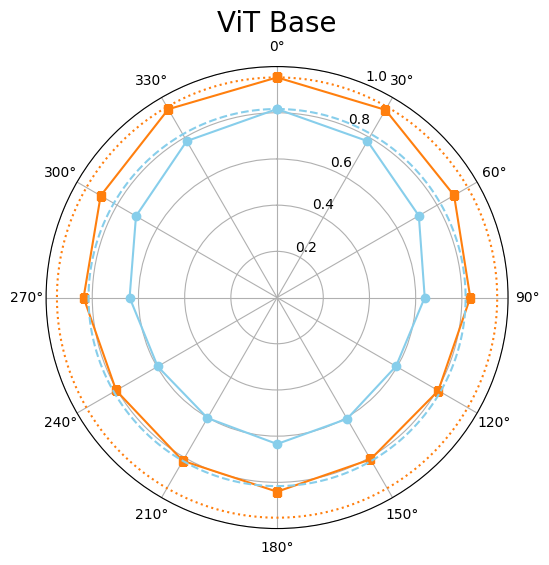

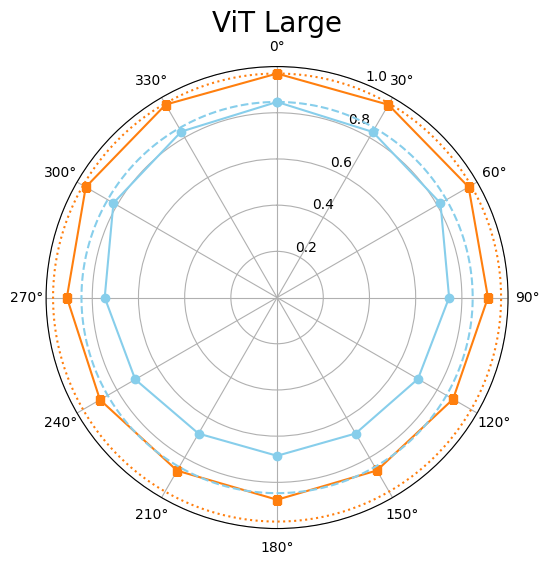

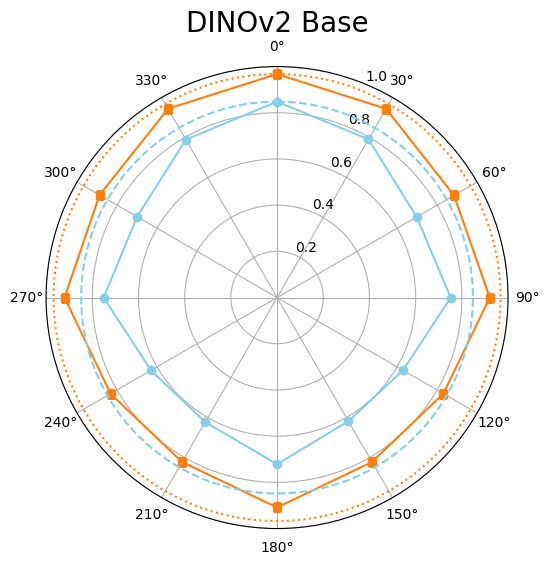

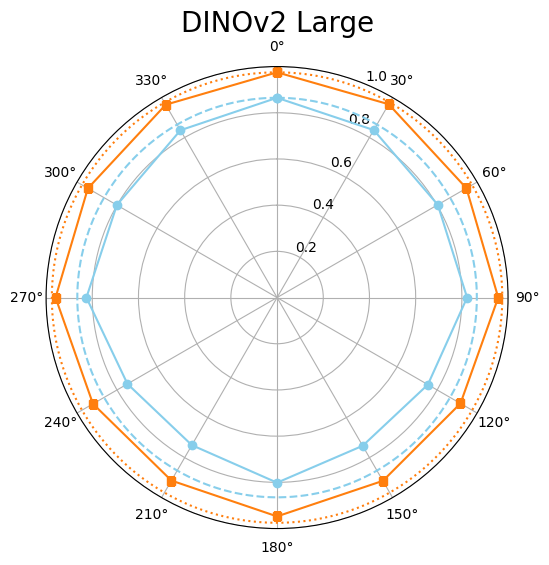

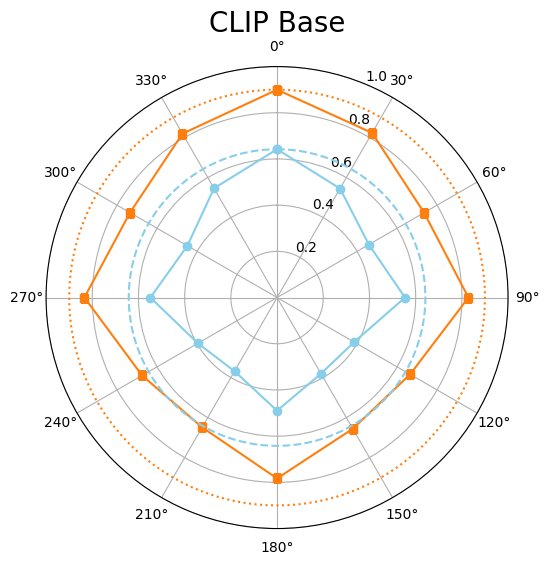

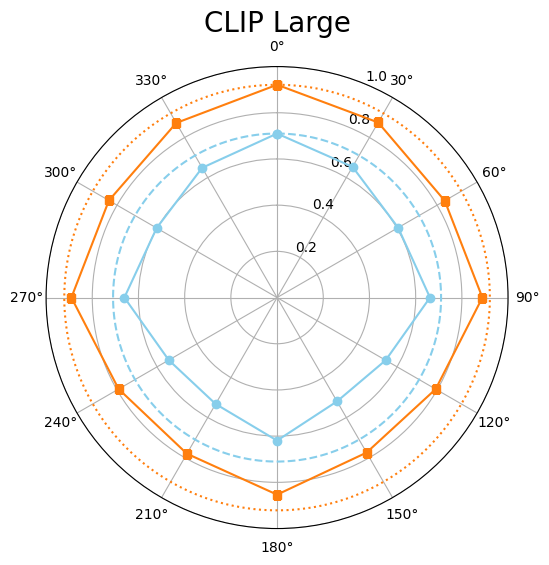

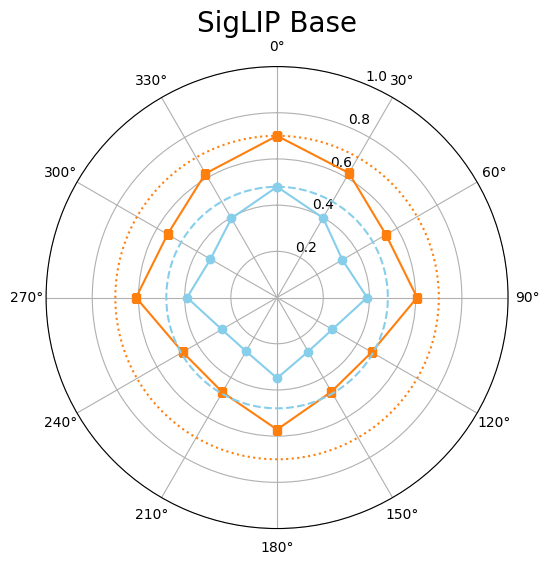

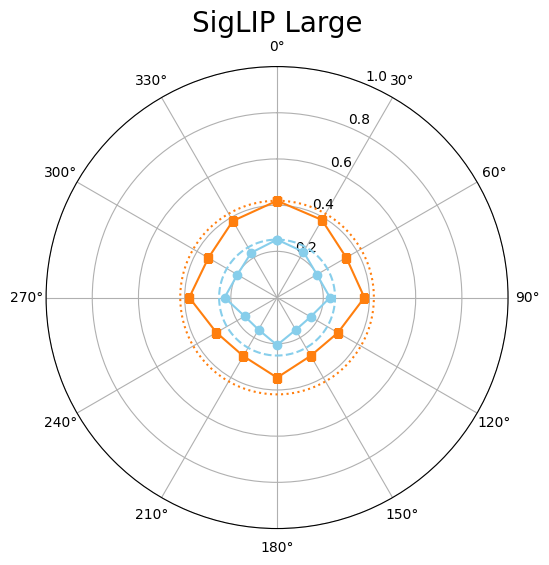

In [45]:
plot_rotations_polar(df, model_name="vit_base", title="ViT Base")
plot_rotations_polar(df, model_name="vit_large", title="ViT Large")
plot_rotations_polar(df, model_name="dinov2_base", title="DINOv2 Base")
plot_rotations_polar(df, model_name="dinov2_large", title="DINOv2 Large")
plot_rotations_polar(df, model_name="clip_base", title="CLIP Base")
plot_rotations_polar(df, model_name="clip_large", title="CLIP Large")
plot_rotations_polar(df, model_name="siglip_base", title="SigLIP Base")
plot_rotations_polar(df, model_name="siglip_large", title="SigLIP Large")

### Scale

In [58]:
def plot_scale_2D(df, model_name="model", title="Title"):
    # locate baseline (no translation, no rotation, scale=1, no shear)
    baseline_row = df[
        (df["Model Name"] == model_name)
        & (df["Translation X"] == 0)
        & (df["Translation Y"] == 0)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] == 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
    ]
    if baseline_row.empty:
        print("Baseline row not found!")
        return
    baseline_top1 = baseline_row["Top-1 Accuracy"].values[0]
    baseline_top5 = baseline_row["Top-5 Accuracy"].values[0]

    # filter rows with translations at ±25 and ±50 (only translations, no other augmentations)
    scaling_rows = df[
        (df["Model Name"] == model_name)
        & (df["Translation X"] == 0)
        & (df["Translation Y"] == 0)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] != 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
    ]

    top1s = scaling_rows["Top-1 Accuracy"].values
    top5s = scaling_rows["Top-5 Accuracy"].values

    # print("Top-1 Accuracies for scaling:", top1s)
    # print("Top-5 Accuracies for scaling:", top5s)

    # bar plot
    x = np.arange(len(top1s) + 1)  # positions for bars
    width = 0.35  # width of bars

    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.bar(x - width/2, list([top1s[0]]) + list([baseline_top1]) + list(top1s[1:]), width, label='Top-1 Accuracy', color='skyblue')
    bars2 = ax.bar(x + width/2, list([top5s[0]]) + list([baseline_top5]) + list(top5s[1:]), width, label='Top-5 Accuracy', color='orange')

    # place a dotted line at the baseline values
    ax.axhline(baseline_top1, color='skyblue', linestyle='--', label='Baseline Top-1')
    ax.axhline(baseline_top5, color='orange', linestyle=':', label='Baseline Top-5')

    ax.set_xlabel('Scaling')
    ax.set_ylabel('Accuracy')
    ax.set_title(f"{title}", fontsize=20)
    ax.set_ylim(0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(['0.5x', 'Baseline', '1.5x', '2.0x'])

    # Set the axis fontsize to 16
    ax.tick_params(axis='both', which='major', labelsize=16)

    # set the axis titlesize to 18
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # ax.legend(loc="center", framealpha=1.0)

    plt.savefig(f"{PLOT_FOLDER}{model_name}_scales_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

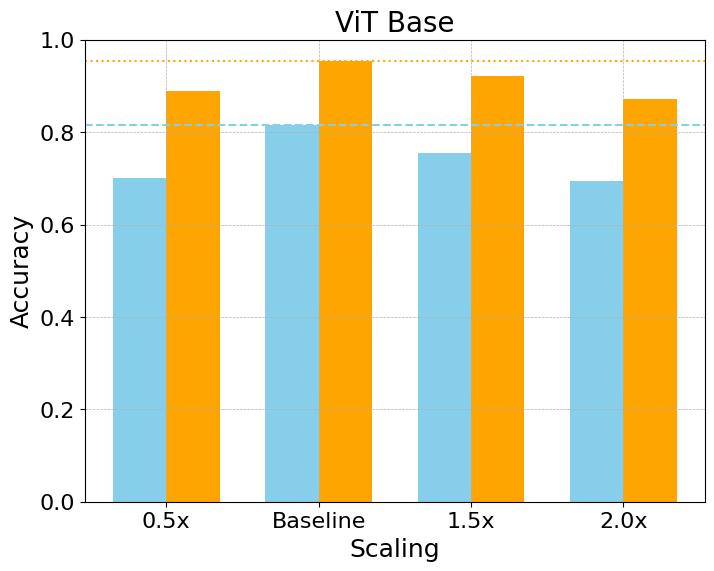

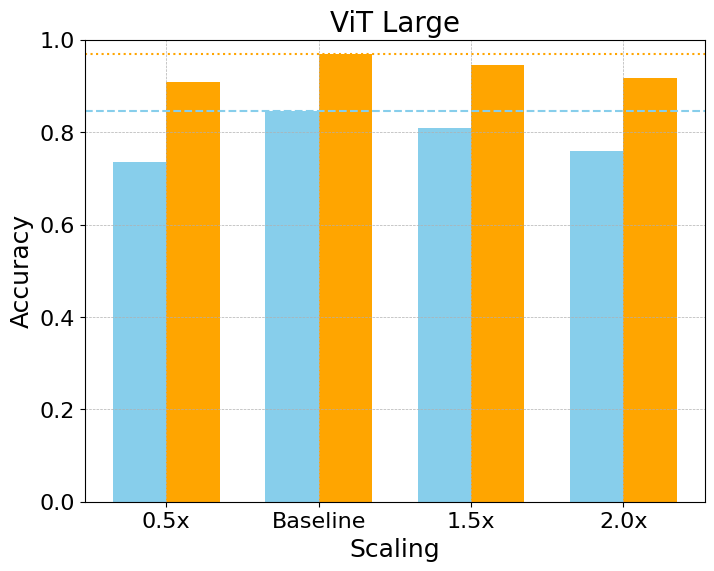

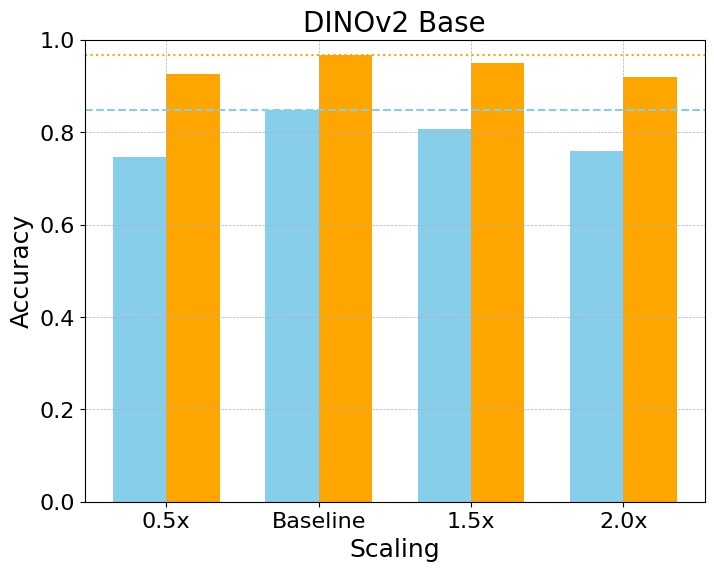

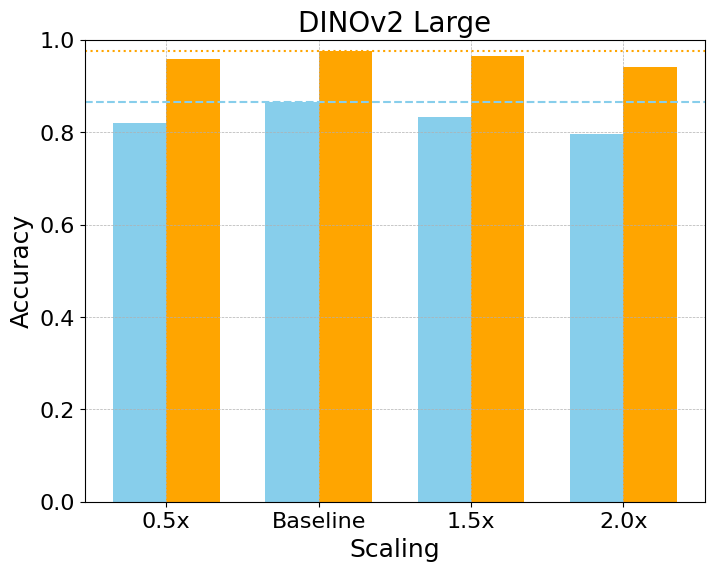

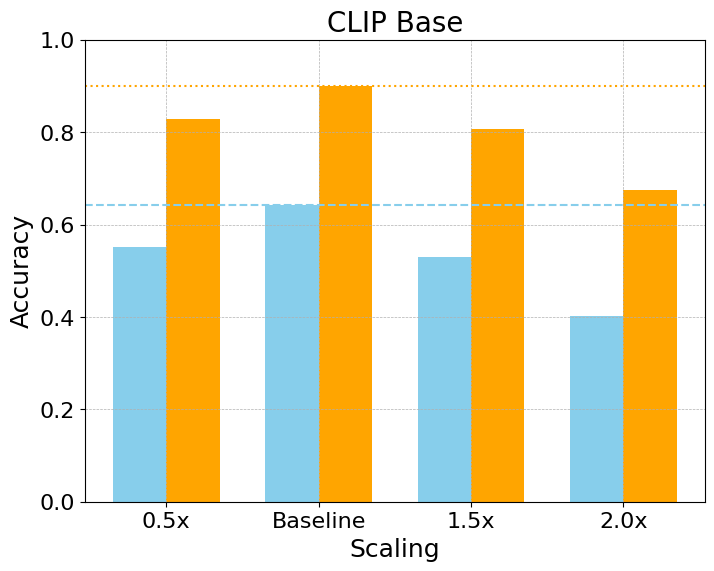

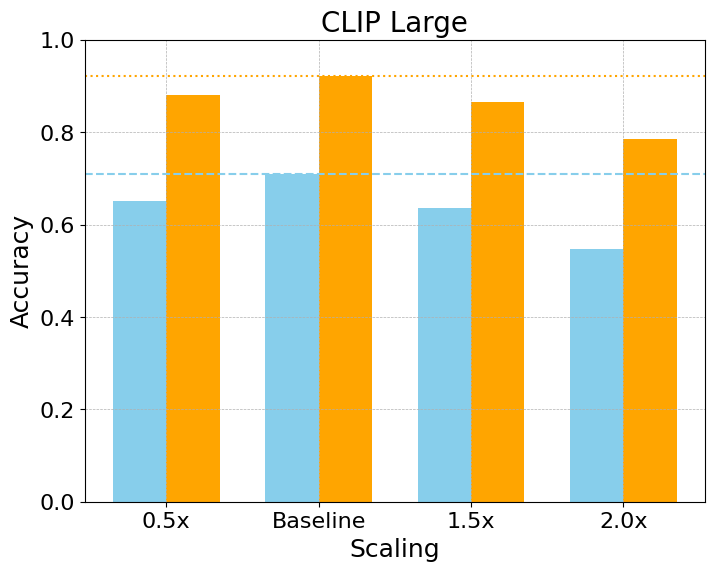

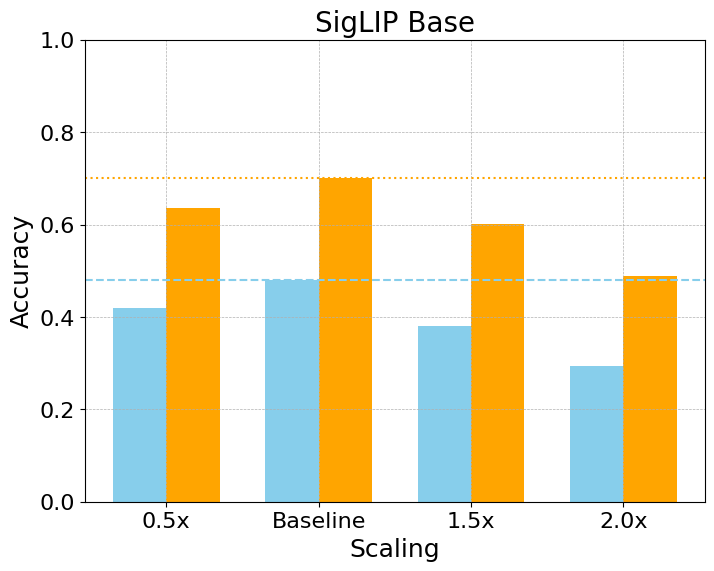

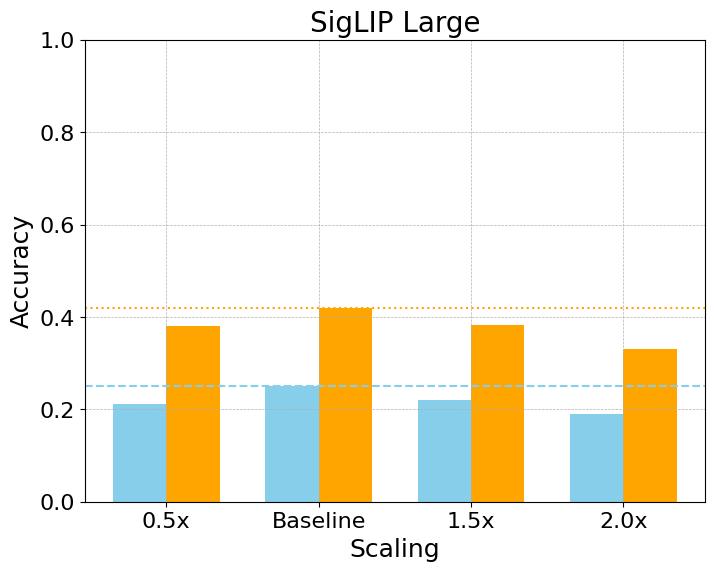

In [59]:
plot_scale_2D(df, model_name="vit_base", title="ViT Base")
plot_scale_2D(df, model_name="vit_large", title="ViT Large")
plot_scale_2D(df, model_name="dinov2_base", title="DINOv2 Base")
plot_scale_2D(df, model_name="dinov2_large", title="DINOv2 Large")
plot_scale_2D(df, model_name="clip_base", title="CLIP Base")
plot_scale_2D(df, model_name="clip_large", title="CLIP Large")
plot_scale_2D(df, model_name="siglip_base", title="SigLIP Base")
plot_scale_2D(df, model_name="siglip_large", title="SigLIP Large")

### Shearing

In [60]:
def plot_shearing_2D(df, model_name="model", title="Title"):
    # locate baseline (no translation, no rotation, scale=1, no shear)
    baseline_row = df[
        (df["Model Name"] == model_name)
        & (df["Translation X"] == 0)
        & (df["Translation Y"] == 0)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] == 1.0)
        & (df["Shear X"] == 0)
        & (df["Shear Y"] == 0)
    ]
    if baseline_row.empty:
        print("Baseline row not found!")
        return
    baseline_top1 = baseline_row["Top-1 Accuracy"].values[0]
    baseline_top5 = baseline_row["Top-5 Accuracy"].values[0]

    # filter rows with translations at ±25 and ±50 (only translations, no other augmentations)
    shearing_rows = df[
        (df["Model Name"] == model_name)
        & (df["Rotation"] == 0.0)
        & (df["Scale"] == 1.0)
        & (df["Translation X"] == 0)
        & (df["Translation Y"] == 0)
        & (
            ((abs(df["Shear X"]) == 25) & (df["Shear Y"] == 0)) |
            ((df["Shear X"] == 0) & (abs(df["Shear Y"]) == 25)) |
            ((abs(df["Shear X"]) == 50) & (df["Shear Y"] == 0)) |
            ((df["Shear X"] == 0) & (abs(df["Shear Y"]) == 50))
        )
    ]

    # group by translation magnitude (25 or 50)
    shearing_rows = shearing_rows.copy()
    shearing_rows["magnitude"] = np.where(
        (abs(shearing_rows["Shear X"]) == 25) | (abs(shearing_rows["Shear Y"]) == 25),
        25,
        50
    )

    # average top-1 and top-5 for each magnitude
    avg_results = shearing_rows.groupby("magnitude")[["Top-1 Accuracy", "Top-5 Accuracy"]].mean().reset_index()

    # prepare data for bar plot
    magnitudes = avg_results["magnitude"].values
    top1_avgs = avg_results["Top-1 Accuracy"].values
    top5_avgs = avg_results["Top-5 Accuracy"].values

    # bar plot
    x = np.arange(len(magnitudes)+1)  # positions for bars
    width = 0.35  # width of bars

    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.bar(x - width/2, [baseline_top1] + list(top1_avgs), width, label='Top-1 Accuracy', color='skyblue')
    bars2 = ax.bar(x + width/2, [baseline_top5] + list(top5_avgs), width, label='Top-5 Accuracy', color='orange')

    # place a dotted line at the baseline values
    ax.axhline(baseline_top1, color='skyblue', linestyle='--', label='Baseline Top-1')
    ax.axhline(baseline_top5, color='orange', linestyle=':', label='Baseline Top-5')

    # add baseline bars at position 0
    # ax.bar(-width/2, baseline_top1, width, color='skyblue')
    # ax.bar(width/2, baseline_top5, width, color='orange')

    ax.set_xlabel('Shear Magnitude')
    ax.set_ylabel('Accuracy')
    ax.set_title(f"{title}", fontsize=20)
    ax.set_ylim(0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(['Baseline'] + [f'{int(m)}' for m in magnitudes])

    # Set the axis fontsize to 16
    ax.tick_params(axis='both', which='major', labelsize=16)

    # set the axis titlesize to 18
    ax.xaxis.label.set_size(18)
    ax.yaxis.label.set_size(18)

    # ax.legend(loc="center", framealpha=1.0)

    plt.savefig(f"{PLOT_FOLDER}{model_name}_shearing_bar.png", dpi=300, bbox_inches="tight")
    plt.show()

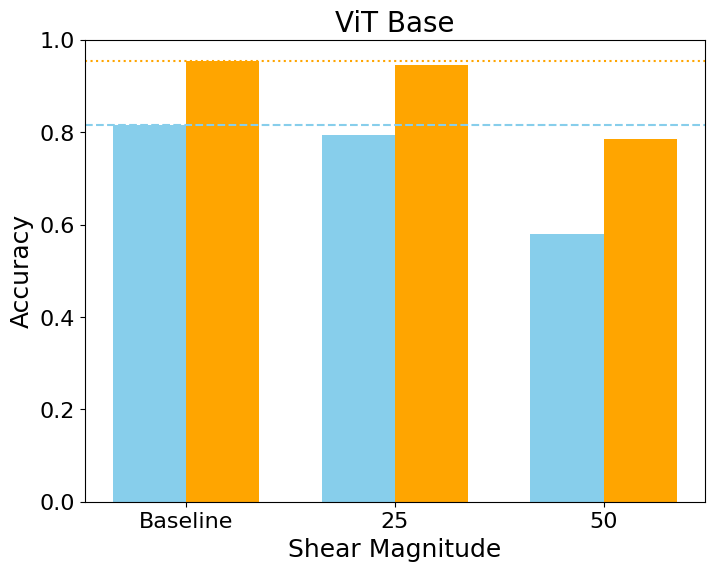

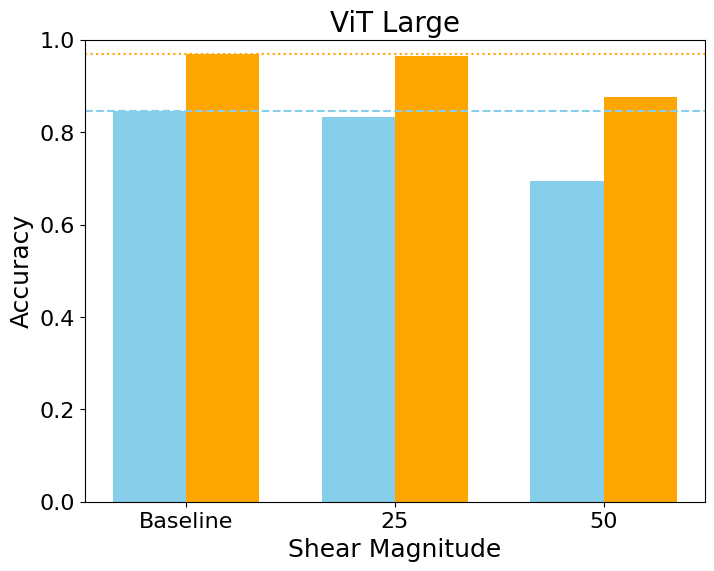

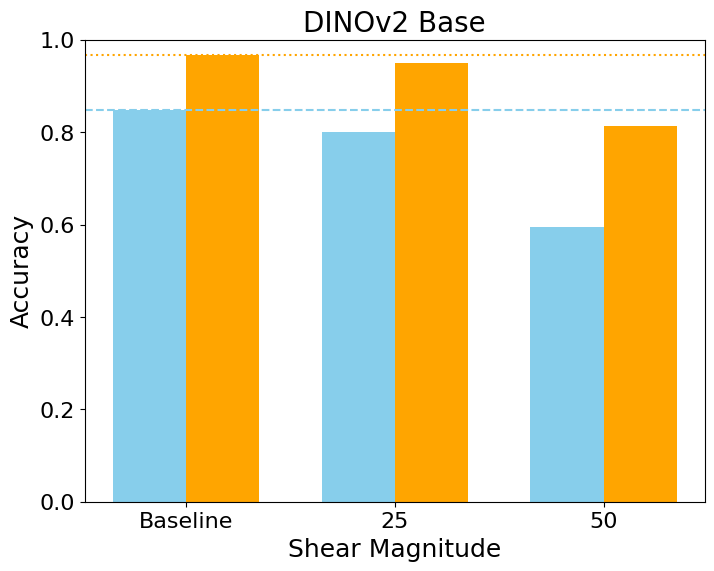

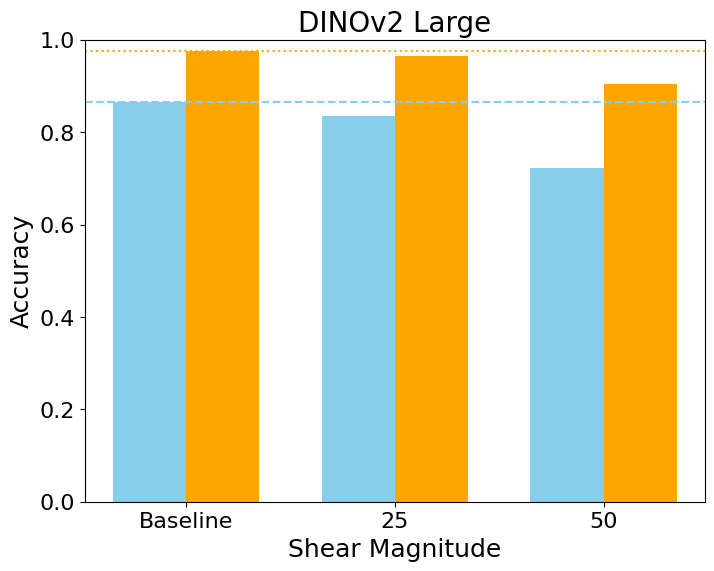

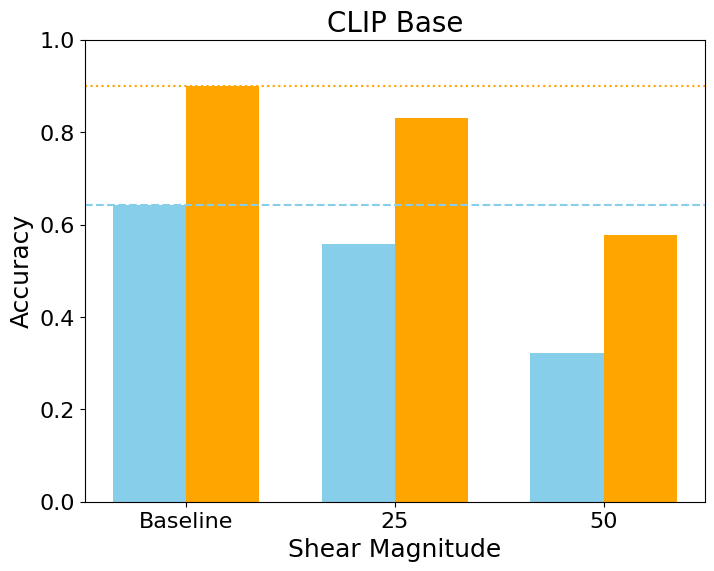

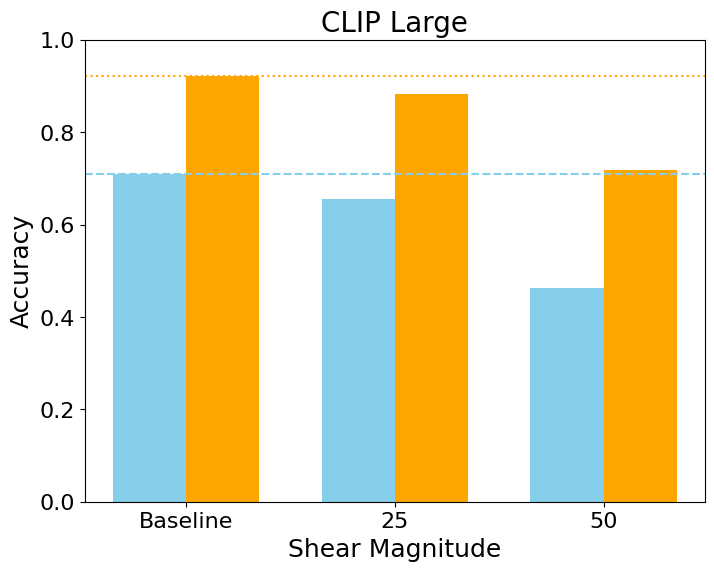

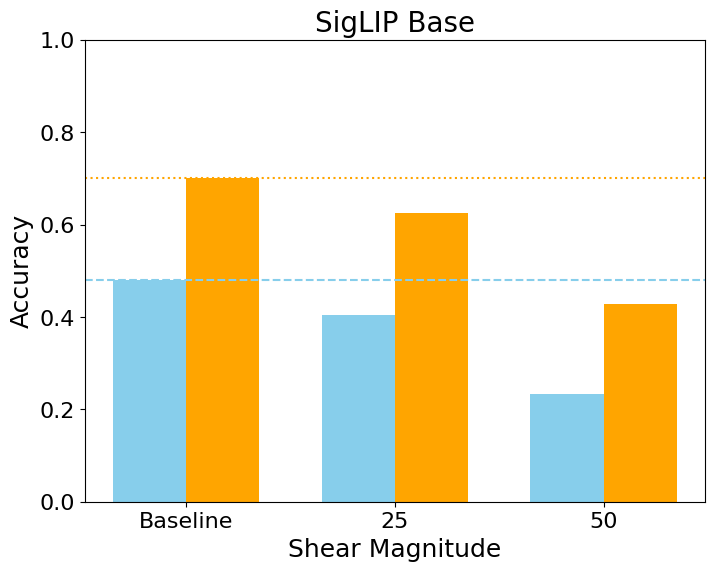

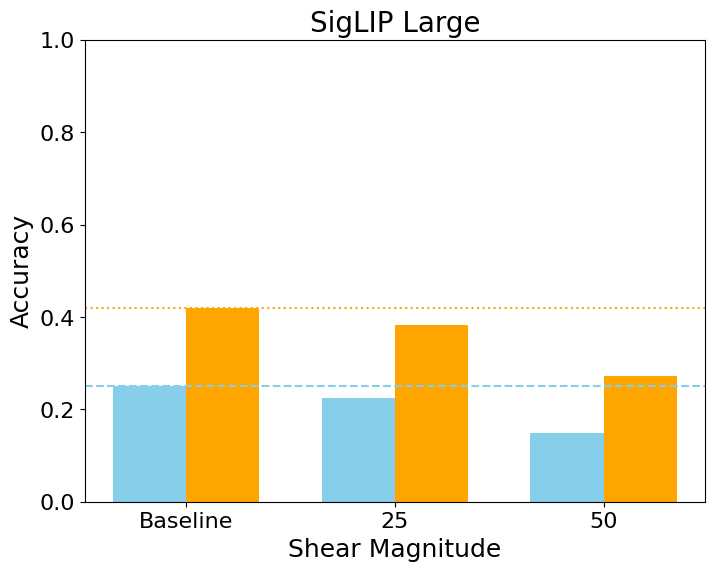

In [61]:
plot_shearing_2D(df, model_name="vit_base", title="ViT Base")
plot_shearing_2D(df, model_name="vit_large", title="ViT Large")
plot_shearing_2D(df, model_name="dinov2_base", title="DINOv2 Base")
plot_shearing_2D(df, model_name="dinov2_large", title="DINOv2 Large")
plot_shearing_2D(df, model_name="clip_base", title="CLIP Base")
plot_shearing_2D(df, model_name="clip_large", title="CLIP Large")
plot_shearing_2D(df, model_name="siglip_base", title="SigLIP Base")
plot_shearing_2D(df, model_name="siglip_large", title="SigLIP Large")

##### Shearing Example

In [69]:
import random
from torch.utils.data import Subset
import torchvision.transforms.functional as TF
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


data_dir = "./imagenet_validation"      # Download from https://www.kaggle.com/datasets/tusonggao/imagenet-validation-dataset

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)

n_samples = 5000
indices = random.sample(range(len(dataset)), n_samples)
subset = Subset(dataset, indices)

loader = DataLoader(
    subset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
)

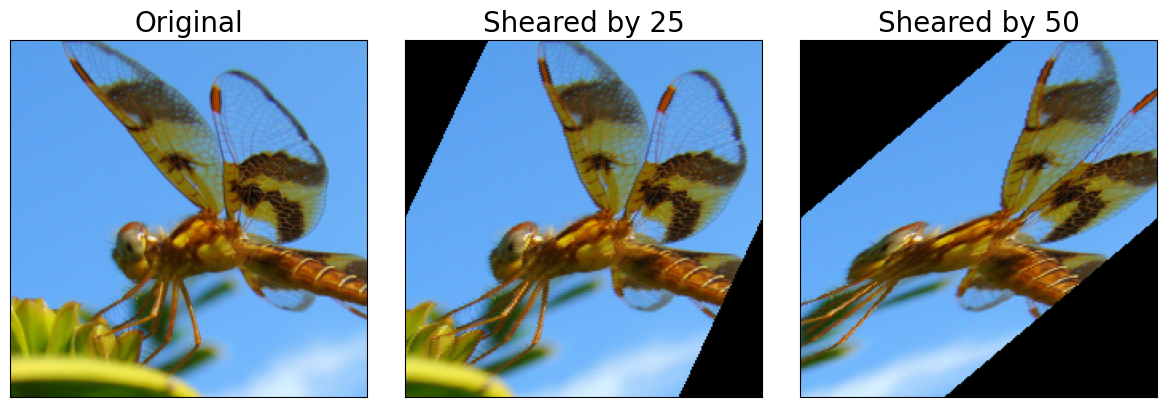

In [74]:
# Apply a shearing transformation of 25 and 50 to a random image and plot the results
img = loader.dataset[1000][0]  # get the first image tensor from the dataset
img25 = TF.affine(img, translate=[0, 0], angle=0.0, scale=1.0, shear=(25, 0))
img50 = TF.affine(img, translate=[0, 0], angle=0.0, scale=1.0, shear=(50, 0))

# Plot the original, sheared by 25, and sheared by 50 images side by side
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(img.permute(1, 2, 0).numpy())
axs[0].set_title("Original", fontsize=20)
axs[1].imshow(img25.permute(1, 2, 0).numpy())
axs[1].set_title("Sheared by 25", fontsize=20)
axs[2].imshow(img50.permute(1, 2, 0).numpy())
axs[2].set_title("Sheared by 50", fontsize=20)

# Remove axis ticks
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(f"{PLOT_FOLDER}shearing_examples.png", dpi=300, bbox_inches="tight")
plt.show()

### Summary